# Figure S2 | Selecting embedding parameters with simplex projection

This notebook evaluates univariate simplex projection across the proxy and solar forcing records used in the study. It shows how out-of-sample one-step forecast skill changes with embedding dimension ($E$) and time delay ($\tau$), providing a transparent basis for assessing the parameter space used in empirical dynamic modeling.

**Reading guide.** The workflow (1) assembles and mean-centers each time series, (2) runs a grid of simplex forecasts, and (3) summarizes Pearson correlation skill ($\rho$) as a heatmap for each record.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from operator import index
from pathlib import Path
import os
import sys
import itertools


In [3]:
stem = Path(*(p := Path.cwd().resolve()).parts[: p.parts.index("notebooks")])
proj_dir = stem / "hol_temp_tsi_ccm"

figures_dir = stem  / "figures" / "FigS2__simplex"
figures_dir.mkdir(exist_ok=True, parents=True)

PosixPath('/Users/jlanders/PycharmProjects')

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyEDM as pe

import warnings
warnings.filterwarnings("ignore", category=UserWarning)#, module='seaborn')
warnings.filterwarnings("ignore", category=FutureWarning)#, module='seaborn')
warnings.simplefilter("ignore", category=FutureWarning)

from cedarkit.core.data_var import VarObject
from cedarkit.utils.plotting import save_figure
from cedarkit.viz.panels import SimplexGrid
from cedarkit.viz.grids import SummaryGrid


In [5]:
# proj_name = 'mixed'
# proj_dir = stem/'hol_temp_tsi_ccm'/proj_name#'#Path(os.getcwd()).resolve().parents[0]
#
# figures_dir_parent = proj_dir.parent/'PBnotebooks'/'figures'
# notebook_name = 'FigS2__simplex'
# figures_dir = figures_dir_parent / notebook_name
# figures_dir.mkdir(exist_ok=True, parents=True)

## Data assembly

The analysis includes alternative reconstructions of temperature, stable-water-isotope, global-mean surface-temperature, and total-solar-irradiance records. Each named series is loaded once even when it appears in more than one paired project configuration.

In [6]:
var_ids = [
    # Raw
    "NGRIP1Seierstad14d18O", "GISP2Seierstad14d18O", "GISP2Doering22T15N",
    "GISP2Martin24Tanom", "NGRIPMartin24Tanom", "Erb22daGMST",
    "GISP2Alley00Tanom", "Tian22HT115kaALLGMST", "Wu18TSI", "Vieira11TSI",
    # Precomputed linearly detrended
    "NGRIP1Seierstad14d18OLinear", "GISP2Seierstad14d18OLinear", "GISP2Doering22T15NLinear",
    "GISP2Martin24TanomLinear", "NGRIPMartin24TanomLinear", "Erb22daGMSTLinear",
    "GISP2Alley00TanomLinear", "Tian22HT115kaALLGMSTLinear", "Wu18TSILinear", "Vieira11TSILinear",
]

var_obj_d = {}
for var_id in var_ids:
    var_type = "target" if "tsi" in var_id.lower() else "col"
    new_var_obj = VarObject(None, var_id, proj_dir)
    new_var_obj.using_master_config = True
    new_var_obj.get_real()
    new_var_obj.mean = new_var_obj.ts[new_var_obj.col_name].mean()
    new_var_obj.var_type = var_type
    var_obj_d[var_id] = new_var_obj

print(f"Loaded {len(var_obj_d)} simplex series.")

## Simplex projection

For a candidate $E$ and $\tau$, simplex projection reconstructs the state of a time series from lagged copies of itself, identifies the most similar reconstructed states, and uses their subsequent evolution to forecast the series' own next value. Here, the forecast horizon is one time step ($T_p=1$). Skill is measured as the Pearson correlation ($\rho$) between observed and predicted values; higher values indicate more accurate one-step forecasts.

In [7]:
def run_simplex(arg_tuple):
    """
    Run the Simplex algorithm on the provided data and parameters.
    Parameters:
    - arg_tuple: A tuple containing:
        - grp_d: A dictionary with parameters 'E', 'tau', and 'Tp'.
        - df: The DataFrame containing the data.
        - var: The variable to be used for the analysis.
    Returns:
    - metrics: A DataFrame containing the computed metrics.
    - simplex_out: The output of the Simplex algorithm.
    """
    grp_d, df, var = arg_tuple
    # A negative delay selects past observations; the exclusion radius keeps nearby times out of the neighbour search.
    simplex_out = pe.Simplex(dataFrame=df, tau=-grp_d['tau'],lib=[1, len(df)-grp_d['Tp']],
                             pred=[1, len(df)-grp_d['Tp']],
                                         E=grp_d['E'], Tp=grp_d['Tp'], embedded=False, showPlot=False,noTime=False,
                                         columns=var, target=var, exclusionRadius=grp_d['tau']*grp_d['E'])
    metrics = pe.ComputeError(simplex_out.Observations, simplex_out.Predictions)
    metrics['E'] = grp_d['E']
    metrics['tau'] = grp_d['tau']
    metrics['Tp'] = grp_d['Tp']
    metrics['var'] = var
    metrics['alg'] = 'simplex'

    return metrics, simplex_out

### Parameter sweep

The sweep evaluates $E=4$–$9$ and $\tau=1$–$8$. These parameters jointly set the time span represented by an embedding, $(E-1)\tau$. The exclusion radius prevents temporally adjacent points from being treated as nearest neighbours, reducing a source of overly optimistic forecast skill.

In [8]:
metrics_list = []
simplex_list = []

for var, dataset in var_obj_d.items():
    raw_ts = dataset.ts[["time", dataset.col_name]].copy()
    raw_ts[var] = raw_ts.pop(dataset.col_name) - dataset.mean

    # Evaluate the same E–tau grid for every series to make heatmaps directly comparable.
    for E in range(4,10):
        for tau in range(1, 9):
            grp_d = {'E': E, 'tau': tau, 'Tp': 1}
        
            # [config.erb.data_var, config.essel.data_var, config.vieira.data_var, config.wu.data_var]:

            # Compute one-step self-prediction skill for this candidate embedding.
            metrics, simplex_out = run_simplex((grp_d, raw_ts, var))
            metrics['var_label'] = var_obj_d[var].var_label
            metrics_list.append(metrics)
            simplex_list.append(simplex_out)
        

In [9]:
metrics_df = pd.DataFrame(metrics_list)


## Comparing forecast skill

Each row of the result table corresponds to one series and one $(E,\tau)$ combination. The final heatmaps let readers compare the location and breadth of high-skill regions across records, rather than relying on a single preselected parameter pair.

## Interpreting the heatmaps

As you'll see in the figure below, columns group solar forcing, global temperature, GISP2, and NGRIP records, with panels within a column showing the available reconstructions. Color encodes $\rho$, with darker values representing stronger one-step simplex prediction. Broad regions of elevated skill are generally more robust to a particular embedding choice than isolated combinations.

In [10]:

rows_pairs = [['GISP2Alley00Tanom','GISP2Doering22T15N'],
              ['NGRIPMartin24Tanom', 'GISP2Martin24Tanom'], 
              ['NGRIP1Seierstad14d18O', 'GISP2Seierstad14d18O'],
                ['Erb22daGMST', 'Tian22HT115kaALLGMST'],
                ['Wu18TSI', 'Vieira11TSI']
]

In [11]:
TSI_col = 0
GMST_col = 1
GISP2_col = 2
NGRIP_col = 3
col_titles = ['TSI', 'GMST', 'GISP2', 'NGRIP']

col_d = {}
width_ratios = []
for i, col_title in enumerate(col_titles):
    col_d[col_title] = len(width_ratios)
    width_ratios.append(1)
    width_ratios.append(.05)
    if i <len(col_titles)-1:
        width_ratios.append(0.2)
        
reverse_col_d = {v:k for k,v in col_d.items()}
        

Alley00_row = 0
Doering22T15N_row = 1
Martin24_row = 2
Seierstad14_row = 3
erb_row = 0
wu_row = 0
vieira_row = 1
tian_row = 1

grid_d = {(ik, ij): None for ik in range(4) for ij in reverse_col_d.keys()}
grid_d.update({(wu_row,col_d['TSI']): 'Wu18TSI' , (vieira_row,col_d['TSI']): 'Vieira11TSI',
          (erb_row,col_d['GMST']): 'Erb22daGMST',
            (tian_row,col_d['GMST']): 'Tian22HT115kaALLGMST',
          (Alley00_row, col_d['GISP2']): 'GISP2Alley00Tanom', (Doering22T15N_row, col_d['GISP2']): 'GISP2Doering22T15N', (Martin24_row,col_d['GISP2']): 'GISP2Martin24Tanom', (Seierstad14_row,col_d['GISP2']): 'GISP2Seierstad14d18O',
             (Martin24_row,col_d['NGRIP']): 'NGRIPMartin24Tanom', (Seierstad14_row,col_d['NGRIP']): 'NGRIP1Seierstad14d18O'})

In [13]:
width_ratios = [[1, 0.05, 0.051], [1, 0.05, 0.051], [1, 0.05], [1, 0.05]]

0 0 Wu18TSI
TSI
0 3 Erb22daGMST
GMST
0 6 GISP2Alley00Tanom
GISP2
0 9 None
NGRIP
3 0 title
1 0 Vieira11TSI
TSI
1 3 Tian22HT115kaALLGMST
GMST
1 6 GISP2Doering22T15N
GISP2
1 9 None
NGRIP
2 0 None
TSI
2 3 None
GMST
2 6 GISP2Martin24Tanom
GISP2
2 9 NGRIPMartin24Tanom
NGRIP
3 0 None
TSI
3 3 None
GMST
3 6 GISP2Seierstad14d18O
GISP2
3 9 NGRIP1Seierstad14d18O
NGRIP
0 3 NGRIP1Seierstad14d18O


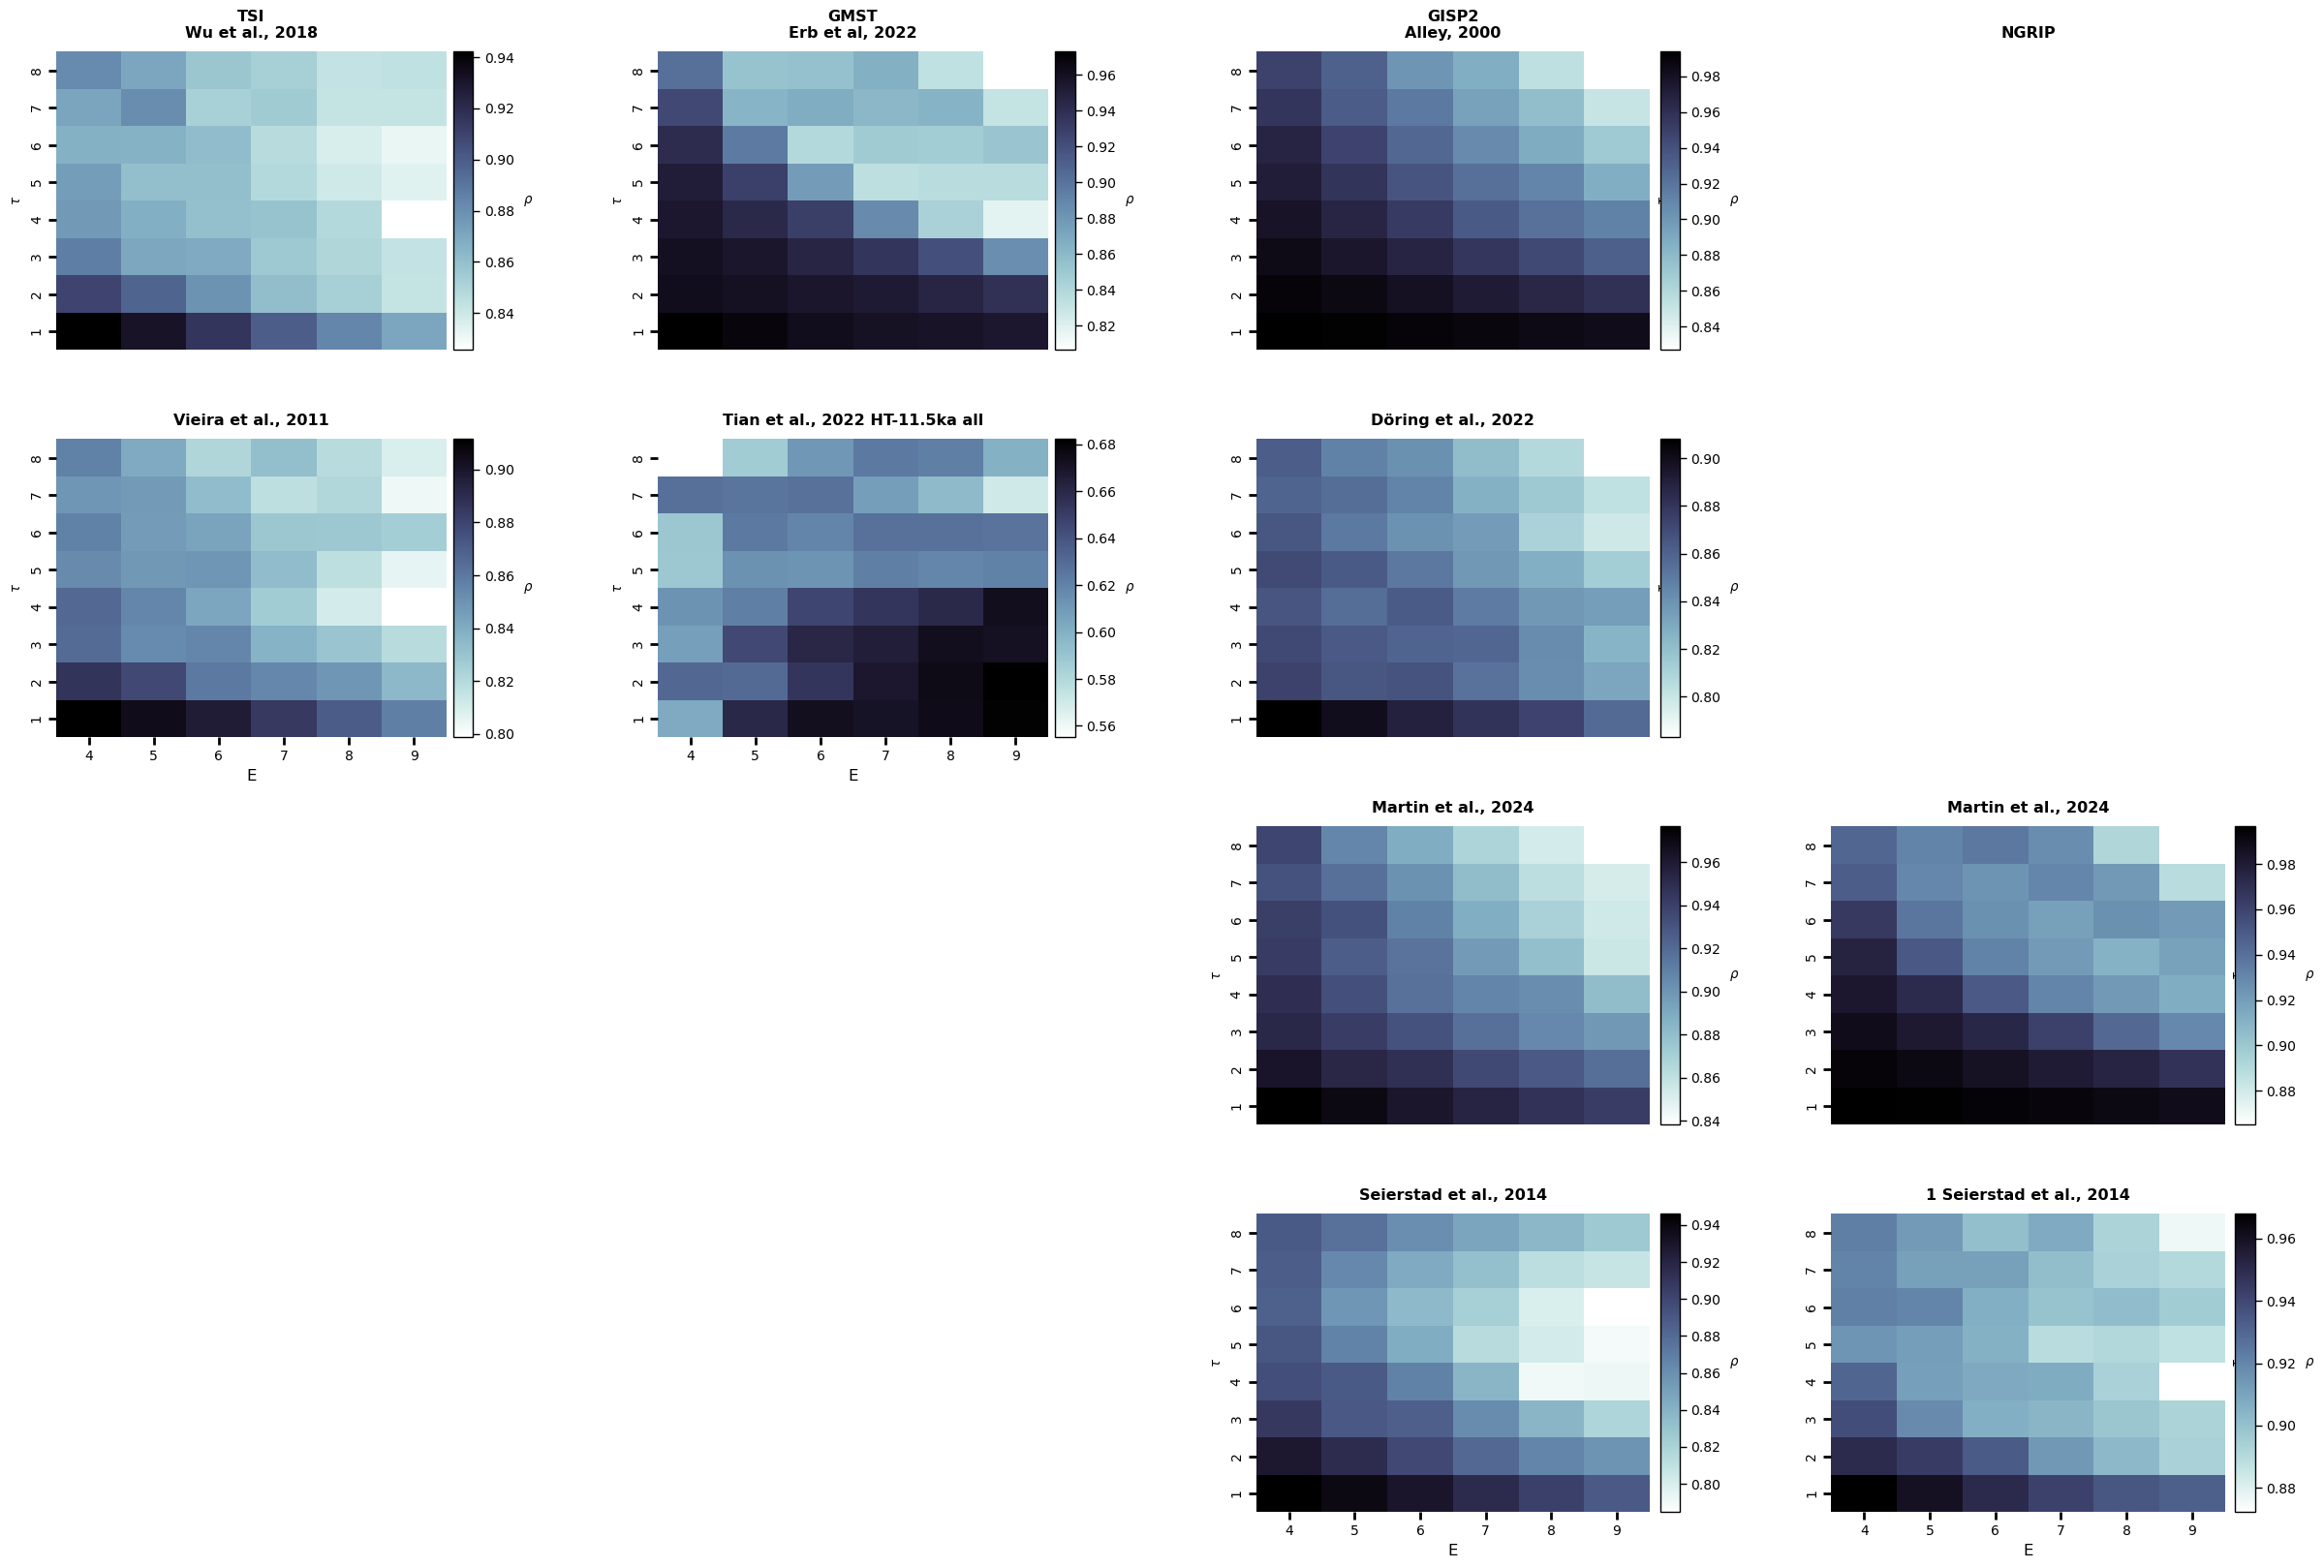

In [14]:
cols = len(col_d)#len(project_pairs)
rows = 4# 2

gridplot = SummaryGrid(rows, len(width_ratios), width_ratios=width_ratios)
gridplot.set_font_sizes(context='poster', multiplier=4)
gridplot.make_grid(figsize=(6*cols, 4*rows), wspace=.051, hspace=0)
pal = sns.cubehelix_palette(start=.15, rot=-.28, light=1,dark=0, gamma=1, reverse=False, as_cmap=True)

for (row, col), var in grid_d.items():
    stem = reverse_col_d[col]
    col = int(col/3)
    col_ind = 0
    col_ind_cbar = col_ind+1
    ax = gridplot.get_ax(row, col, col_ind)
    cbar_ax = gridplot.get_ax(row, col, col_ind_cbar)
    
    if var is None:
        if row == 0:
            title = stem
            ax.set_title(title, fontsize='large', fontweight='bold', pad=15)
            print(col, row, 'title')
            gridplot.set_ax(row, col, ax,subfig_col=col_ind, entry_type='title')
        else:
            gridplot.set_ax(row, col, ax,subfig_col=col_ind, entry_type=None)
        gridplot.set_ax(row, col, cbar_ax, subfig_col=col_ind_cbar, entry_type=None)
        if col_ind+2 < len(width_ratios):
            ax_spacer = gridplot.get_ax(row, col, col_ind+2)
            gridplot.set_ax(row, col, ax_spacer,subfig_col = col_ind+2, entry_type='spacer')
        continue
    
    # One panel summarizes rho across the complete E–tau grid for a single record.
    test_grid = SimplexGrid(x_var='E', y_var='tau', hue_var='rho', ax=ax, palette=pal)

    test_grid.ylabel = r'$\tau$'
    title= var_obj_d[var].var_label.replace(stem,'').replace(';','').strip()
    test_grid.title = title
    if row == 0:
        test_grid.title = '\n'.join([stem, test_grid.title])

    test_grid.ylabel = var_obj_d[var].var_label + '\n' + r'$\tau$'
    test_grid.ylabel = r'$\tau$'
    simplex_df = metrics_df[metrics_df['var']==var]
    test_grid.plot_heatmap(grid_df=simplex_df)
    # Limit the displayed color range to keep high-skill regions visually comparable between panels.
    test_grid.vmax = 1 if test_grid.vmax >.85 else min([1, test_grid.vmax+.05])
    test_grid.make_colorbar(cbar_ax=cbar_ax, label=r'$\rho$')
    test_grid.tidy_grid()
    gridplot.set_ax(row, col, test_grid.ax, subfig_col=col_ind, entry_type='plot')
    gridplot.set_ax(row, col, test_grid.cbar_ax,subfig_col=col_ind_cbar, entry_type='cbar')
    if col_ind+2 < len(width_ratios):
        ax_spacer = gridplot.get_ax(row, col, subfig_col=col_ind+2)
        gridplot.set_ax(row, col, ax_spacer,subfig_col=col_ind+2, entry_type='spacer')

final_col_ax = gridplot.get_ax(0, 3,0)
gridplot.tidy_rows(supylabels=False,keep_ylabels=True, keep_titles='individual')


# save_figure(gridplot.fig, figures_dir, stem="FigS2_simplex", dry_run=True)



TSI and the various temperature/δ¹⁸O series each peak in self-prediction skill at a different (E, τ) combination, so no single pair is optimal for every TSI–climate dyad. This is exactly why the causal analysis in later notebooks doesn't settle on one compromise pair: it sweeps E = 4–10 and τ = 1–8 (49 configurations) — a wider grid than this notebook's own self-prediction search — for the actual cross-mapping analysis, and reports how consistently a causal signal shows up across that whole grid rather than at a single "best" point.